# Lakeside sklearn — results viewer

**Training does not run in this notebook** (avoids dead Jupyter kernels).

```powershell
cd vibe_code_apps_22
$env:VIBE22_ALLOW_CLI_TRAIN="1"
python scripts/train_four_arms.py --profile full_evaluation
```

Arms: `sklearn_winter`, `sklearn_allyear`, `torch_winter`, `torch_allyear`  
Artifacts: `ml/artifacts/runs/<arm>/`


In [1]:
%matplotlib inline
from datetime import datetime
print("KERNEL ALIVE", datetime.now().isoformat(timespec="seconds"), flush=True)

import json, os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT / "ml"))
sys.path.insert(0, str(ROOT / "scripts"))

from artifact_paths import artifact_paths
from notebook_plots import apply_notebook_theme, save_fig, metric_cards_html
from timing_utils import format_hms

apply_notebook_theme()
PATHS = artifact_paths()
OUT = PATHS["figures"].parent
FIG = PATHS["figures"]
FIG.mkdir(parents=True, exist_ok=True)
RUNS = OUT / "runs"
INDEX = RUNS / "index.json"

print("ROOT", ROOT)
print("RUNS", RUNS, "exists", RUNS.is_dir())
print("INDEX", INDEX, "exists", INDEX.is_file())
if not INDEX.is_file():
    display(Markdown(
    "**No `runs/index.json` yet.** Train outside Jupyter:\n\n"
    "```powershell\n"
    "cd vibe_code_apps_22\n"
    "$env:VIBE22_ALLOW_CLI_TRAIN='1'\n"
    "python scripts/train_four_arms.py --profile full_evaluation\n"
    "# fast debug: python scripts/train_four_arms.py --profile smoke\n"
    "```\n"
    ))
print("SETUP COMPLETE", flush=True)


KERNEL ALIVE 2026-08-10T08:08:18


ROOT C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22
RUNS C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\runs exists True
INDEX C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\ml\artifacts\runs\index.json exists True
SETUP COMPLETE


## Load run index + cards


In [2]:
def _read_json(p: Path):
    if not p.is_file():
        return None
    return json.loads(p.read_text(encoding="utf-8"))

index = _read_json(INDEX) or {"results": [], "note": "missing index — run train_four_arms.py"}
rows = []
for arm_dir in sorted(RUNS.glob("*")):
    if not arm_dir.is_dir():
        continue
    arm = arm_dir.name
    timing = _read_json(arm_dir / "timing.json") or {}
    result = _read_json(arm_dir / "result.json") or {}
    # pick card by family
    if arm.startswith("sklearn"):
        card_path = arm_dir / "real_baseline_15min_v1_model_card.json"
    else:
        card_path = arm_dir / "real_baseline_15min_torch_v1_model_card.json"
    card = _read_json(card_path) or {}
    tf = card.get("cv_teacher_forced") or {}
    rec = card.get("cv_recursive_96_heldout") or {}
    champ = card.get("champion") or card.get("family")
    if isinstance(rec, dict) and champ in rec and isinstance(rec[champ], dict):
        rec_block = rec[champ]
    else:
        rec_block = rec if isinstance(rec, dict) else {}
    rows.append({
        "arm": arm,
        "ok": result.get("ok"),
        "winter_only": timing.get("winter_only", result.get("winter_only")),
        "n_days": timing.get("n_days", result.get("n_days")),
        "train_hms": timing.get("total_hms") or result.get("timing_hms") or result.get("wall_hms"),
        "train_s": timing.get("total_seconds") or result.get("wall_seconds"),
        "champion": champ,
        "peak_mae_kw": rec_block.get("facility_kw_mae_peak_05_09") or tf.get("facility_kw_mae_peak_05_09"),
        "zone_mae_f": rec_block.get("zone_temp_mae_mean") or tf.get("zone_temp_mae_mean"),
        "card": str(card_path) if card_path.is_file() else None,
        "timing_file": str(arm_dir / "timing.json") if (arm_dir / "timing.json").is_file() else None,
    })

summary = pd.DataFrame(rows)
if summary.empty:
    display(Markdown("No arm folders under `ml/artifacts/runs/` yet."))
else:
    display(Markdown("### Train arms — wall clock + key metrics"))
    display(summary)
    display(Markdown(
        f"Launcher wall (all arms): **{format_hms(index.get('wall_seconds'))}** · "
        f"ok={index.get('ok_count')} fail={index.get('fail_count')}"
    ))


### Train arms — wall clock + key metrics

,arm,ok,winter_only,n_days,train_hms,train_s,champion,peak_mae_kw,zone_mae_f,card,timing_file
0,sklearn_allyear,True,False,36,0h 07m 07s,426.626676,extra_trees_native_multi,20.043088,0.343604,C:\Users\ben\Documents\py-bacnet-stacks-playgr...,C:\Users\ben\Documents\py-bacnet-stacks-playgr...
1,sklearn_winter,True,True,151,0h 45m 05s,2705.104179,extra_trees,37.519259,1.166814,C:\Users\ben\Documents\py-bacnet-stacks-playgr...,C:\Users\ben\Documents\py-bacnet-stacks-playgr...
2,torch_allyear,True,False,335,0h 13m 40s,820.358652,resmlp_dualhead,40.572197,1.817601,C:\Users\ben\Documents\py-bacnet-stacks-playgr...,C:\Users\ben\Documents\py-bacnet-stacks-playgr...
3,torch_winter,True,True,151,0h 09m 46s,585.846209,resmlp_dualhead,74.805157,2.346778,C:\Users\ben\Documents\py-bacnet-stacks-playgr...,C:\Users\ben\Documents\py-bacnet-stacks-playgr...


Launcher wall (all arms): **1h 22m 31s** · ok=4 fail=0

## Train times


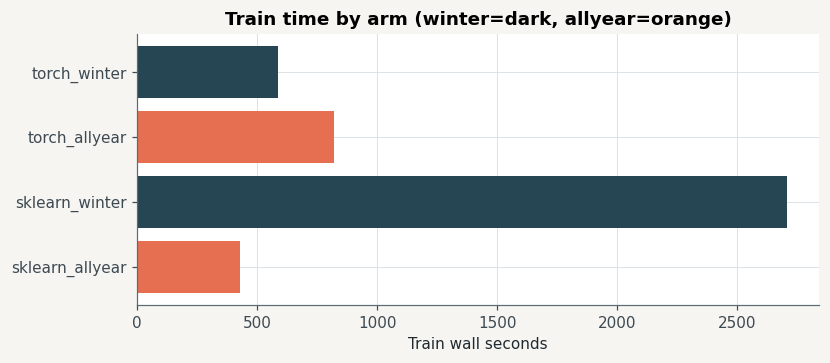

In [3]:
if not summary.empty and summary["train_s"].notna().any():
    plot_df = summary.dropna(subset=["train_s"]).sort_values("arm")
    fig, ax = plt.subplots(figsize=(8, 3.2))
    colors = ["#264653" if w else "#e76f51" for w in plot_df["winter_only"].fillna(False)]
    ax.barh(plot_df["arm"], plot_df["train_s"], color=colors)
    ax.set_xlabel("Train wall seconds")
    ax.set_title("Train time by arm (winter=dark, allyear=orange)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    save_fig(FIG / "runs_train_times.png", fig)
    plt.close(fig)
else:
    display(Markdown("No timing seconds to plot yet."))


In [4]:
# Per-arm timing breakdown
for arm in summary["arm"].tolist() if not summary.empty else []:
    tpath = RUNS / arm / "timing.json"
    timing = _read_json(tpath)
    if not timing:
        continue
    display(Markdown(f"#### `{arm}` — {timing.get('total_hms', 'n/a')}"))
    ents = timing.get("entries") or []
    if ents:
        display(pd.DataFrame(ents))
    else:
        print("(no step timings)")


#### `sklearn_allyear` — 0h 07m 07s

,name,seconds,hms
0,load_frame,0.057562,0h 00m 0.1s
1,split_manifest,0.043767,0h 00m 0.0s
2,lean_bake_off,425.060720,0h 07m 05s
3,export_artifacts,1.464628,0h 00m 1.5s


#### `sklearn_winter` — 0h 45m 05s

,name,seconds,hms
0,load_frame,0.106969,0h 00m 0.1s
1,split_manifest,0.217842,0h 00m 0.2s
2,lean_bake_off,2619.677760,0h 43m 40s
3,export_artifacts,85.101608,0h 01m 25s


#### `torch_allyear` — 0h 13m 40s

,name,seconds,hms
0,load_frame,0.073231,0h 00m 0.1s
1,split_manifest,0.508419,0h 00m 0.5s
2,train_torch_baseline,819.436990,0h 13m 39s
3,export_artifacts,0.340012,0h 00m 0.3s


#### `torch_winter` — 0h 09m 46s

,name,seconds,hms
0,load_frame,0.081121,0h 00m 0.1s
1,split_manifest,0.221943,0h 00m 0.2s
2,train_torch_baseline,584.752582,0h 09m 45s
3,export_artifacts,0.790563,0h 00m 0.8s


## Sklearn metrics (winter vs all-year)


In [5]:
FAMILY = 'sklearn'
from IPython.display import HTML

# Side-by-side metric cards for winter vs allyear within this notebook's family
family = FAMILY  # set per notebook
sub = summary[summary["arm"].str.startswith(family)] if not summary.empty else summary
if sub.empty:
    display(Markdown(f"No `{family}_*` arms found."))
else:
    cards = []
    for _, r in sub.iterrows():
        cards.append({
            "label": r["arm"],
            "value": f"{r['peak_mae_kw']:.2f}" if pd.notna(r["peak_mae_kw"]) else "n/a",
            "unit": "kW peak MAE",
            "hint": f"zone {r['zone_mae_f']:.2f}°F · {r['train_hms']}" if pd.notna(r.get("zone_mae_f")) else str(r["train_hms"]),
        })
    display(HTML(metric_cards_html(cards, title=f"{family} arms")))
    display(sub[["arm", "winter_only", "n_days", "champion", "peak_mae_kw", "zone_mae_f", "train_hms"]])


,arm,winter_only,n_days,champion,peak_mae_kw,zone_mae_f,train_hms
0,sklearn_allyear,False,36,extra_trees_native_multi,20.043088,0.343604,0h 07m 07s
1,sklearn_winter,True,151,extra_trees,37.519259,1.166814,0h 45m 05s


## Notes

- Winter = months Nov–Mar; all-year = no month filter (still subject to `--max-days` / profile).
- Peak MAE is recursive held-out when present, else teacher-forced.
- Desktop ship promote remains a separate step (`promote_hybrid_ship.py`) — not part of the four-arm matrix.
